# Phần 3 — Sales Forecasting (tuned)
**Mục tiêu:** dự báo `Revenue` & `COGS` cho 2023-01-01 → 2024-07-01 (548 ngày).

## Ràng buộc đề
1. KHÔNG dùng Revenue/COGS từ test làm feature
2. KHÔNG dùng dữ liệu ngoài
3. Phải tái lập được (set seed)

## Khám phá thực tế
- Tất cả bảng phụ chỉ tới **2022-12-31** → KHÔNG có exogenous cho test period.
- Doanh thu có **regime change** ~2018→2019 (sụt ~40%). Train chỉ trên 2019-2022.
- Pure trend feature (`days_since_start`) gây extrapolation error → BỎ.
- Holiday features (Tết, sale events) help nhỏ nhưng có giá trị giải thích.

## Pipeline
1. EDA & visualize
2. Feature engineering (calendar + cyclic + seasonal + holidays)
3. Honest time-series CV (rebuild seasonal per fold)
4. So sánh variants → chọn config tốt nhất
5. Train full + predict + submit
6. SHAP explainability

## 0 — Setup

In [17]:
# ===== SETUP — import + config =====

import numpy as np                                          # array math, vector ops
import pandas as pd                                         # DataFrame — bảng data chính
import matplotlib.pyplot as plt                             # vẽ biểu đồ
import lightgbm as lgb                                      # gradient boosting model chính
import shap                                                 # explainability — Phần 6
from prophet import Prophet                                 # Facebook Prophet — model phụ trong ensemble
from pathlib import Path                                    # đường dẫn cross-platform
from sklearn.model_selection import TimeSeriesSplit         # CV theo thời gian (KHÔNG shuffle)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # 3 metric đề yêu cầu

# Tắt warning + log rườm rà cho output sạch
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)        # Prophet log nhiều
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)      # Stan = backend của Prophet

# Reproducibility — đề yêu cầu kết quả tái lập được
SEED = 42
np.random.seed(SEED)
DATA = Path('dataset')                                      # data nằm trong subfolder dataset/

# parse_dates: đổi cột "Date" string -> pd.Timestamp ngay khi load
# sort_values + reset_index: data sắp theo thời gian, index = 0..N-1 (cần cho .iloc trong CV)
train      = pd.read_csv(DATA/'sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
sample_sub = pd.read_csv(DATA/'sample_submission.csv', parse_dates=['Date'])

print(f'Train: {train.Date.min().date()} -> {train.Date.max().date()} ({len(train)} ngay)')
print(f'Test:  {sample_sub.Date.min().date()} -> {sample_sub.Date.max().date()} ({len(sample_sub)} ngay)')


Train: 2012-07-04 -> 2022-12-31 (3833 ngay)
Test:  2023-01-01 -> 2024-07-01 (548 ngay)


**Tại sao từng dòng setup?**

- `parse_dates=['Date']` — nếu không có, pandas đọc Date là **string**. String không so sánh được theo thời gian, không dùng được `.dt.month`, `.rolling()`. Phải parse thành `Timestamp`.
- `sort_values('Date')` — CSV không đảm bảo thứ tự. `TimeSeriesSplit` cắt theo **vị trí dòng**, không theo giá trị ngày → nếu không sort, fold sẽ chia sai hoàn toàn.
- `reset_index(drop=True)` — sau sort, index vẫn giữ số cũ (500, 73, 12...). `tscv.split()` trả về position `[0,1,2...]` → `iloc[tr]` và `loc[tr]` cho kết quả khác nhau nếu index không liên tục → bug khó phát hiện.

## 1 — EDA

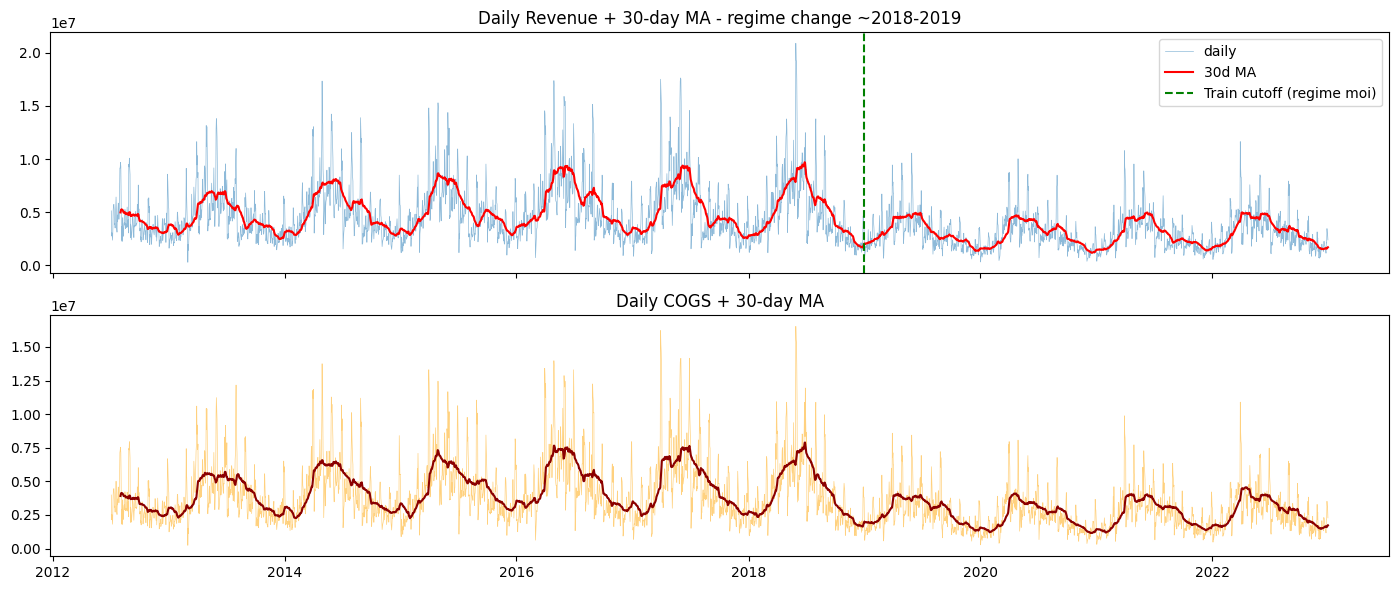

In [18]:
# ===== EDA 1 — Daily Revenue + COGS với 30-day moving average =====
# Mục đích: nhìn mắt phát hiện trend, seasonality, regime change

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
# 2 hàng × 1 cột; sharex=True → 2 subplot share trục x → align Revenue (trên) vs COGS (dưới)

# --- Subplot 1: Revenue ---
ax[0].plot(train.Date, train.Revenue, lw=0.5, alpha=0.5, label='daily')
# line mảnh + mờ → thấy được noise hằng ngày nhưng không che mất trend

ax[0].plot(train.Date, train.Revenue.rolling(30).mean(), color='red', lw=1.5, label='30d MA')
# Moving Average 30 ngày → smooth noise, lộ ra trend + yearly seasonality

ax[0].axvline(pd.Timestamp('2019-01-01'), color='green', linestyle='--', label='Train cutoff (regime moi)')
# vạch đứng đánh dấu mốc TRAIN_START — minh hoạ "regime change" 2018→2019

ax[0].set_title('Daily Revenue + 30-day MA - regime change ~2018-2019'); ax[0].legend()

# --- Subplot 2: COGS (cùng pattern) ---
ax[1].plot(train.Date, train.COGS, lw=0.5, alpha=0.5, color='orange')
ax[1].plot(train.Date, train.COGS.rolling(30).mean(), color='darkred', lw=1.5)
ax[1].set_title('Daily COGS + 30-day MA')

plt.tight_layout()                                           # tránh title bị cắt
plt.show()

**Tại sao EDA là bước quan trọng nhất?**

EDA là nơi phát hiện **quyết định kiến trúc** — không phải chi tiết code. Plot này phát hiện regime change 2018→2019 (revenue sụt ~40%). Nếu bỏ qua và train trên 2012-2022, model học pattern của giai đoạn doanh thu cao → predict 2023 ra số gấp đôi thực tế.

- `rolling(30).mean()` — daily data rất nhiễu. Window 30 ngày đủ smooth để thấy trend mà không mất yearly seasonality.
- `axvline(2019-01-01)` — đánh dấu mốc cắt train, minh hoạ trực quan quyết định regime.

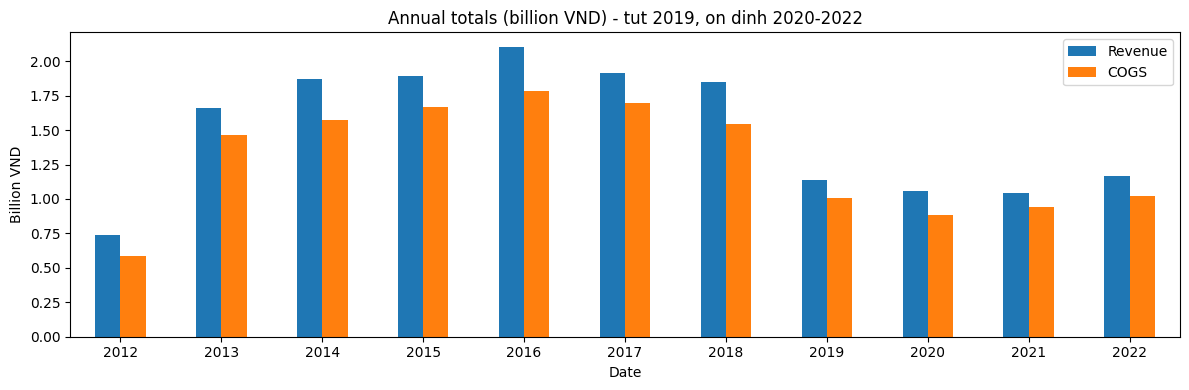

      Revenue  COGS
Date               
2012     0.74  0.59
2013     1.66  1.47
2014     1.87  1.57
2015     1.89  1.67
2016     2.10  1.78
2017     1.91  1.69
2018     1.85  1.54
2019     1.14  1.01
2020     1.05  0.89
2021     1.04  0.94
2022     1.17  1.02


In [19]:
# ===== EDA 2 — Tổng doanh thu/COGS theo NĂM =====
# Cụ thể hoá "regime change" thành con số

annual = train.groupby(train.Date.dt.year)[['Revenue','COGS']].sum() / 1e9
# .dt.year      : tách năm từ Timestamp
# .groupby(...) : nhóm theo năm
# .sum()        : tổng theo nhóm
# / 1e9         : đổi VND → tỷ VND cho dễ đọc

annual.plot(kind='bar', figsize=(12,4), title='Annual totals (billion VND) - tut 2019, on dinh 2020-2022')
plt.ylabel('Billion VND'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(annual.round(2))                                       # in bảng số kèm biểu đồ

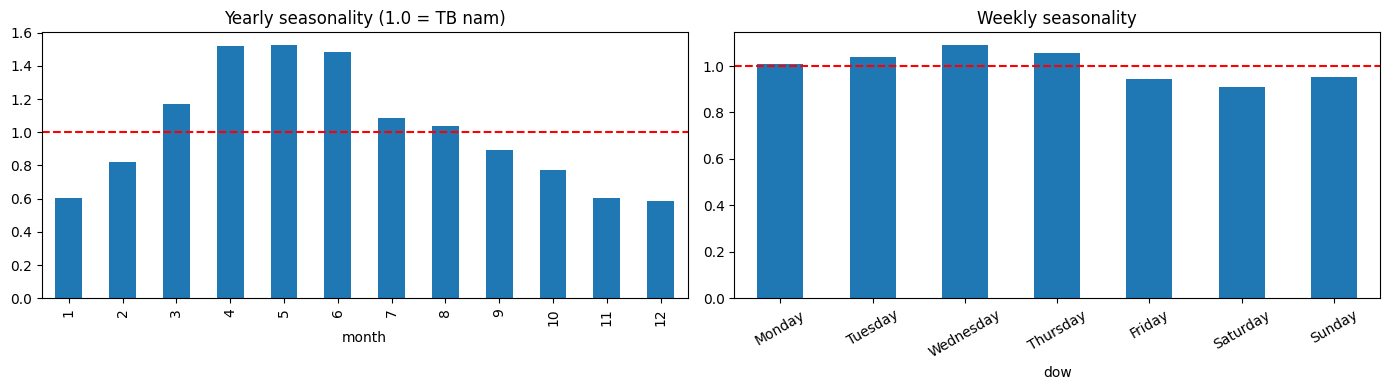

In [20]:
# ===== EDA 3 — Yearly + Weekly seasonality (đã normalize) =====
# Trick: chia cho TB năm → loại bỏ trend giữa các năm, chỉ còn pattern theo tháng/dow

tmp = train.copy()                                           # copy để không sửa train gốc
tmp['year']  = tmp.Date.dt.year
tmp['month'] = tmp.Date.dt.month

# rev_norm = Revenue / mean(Revenue trong cùng năm)
# .transform('mean') broadcast TB của nhóm về từng row (giữ shape gốc — khác .mean() trả 1 số)
tmp['rev_norm'] = tmp['Revenue'] / tmp.groupby('year')['Revenue'].transform('mean')

fig, ax = plt.subplots(1, 2, figsize=(14,4))

# --- Yearly seasonality theo tháng ---
tmp.groupby('month')['rev_norm'].mean().plot(kind='bar', ax=ax[0],
                                             title='Yearly seasonality (1.0 = TB nam)')
ax[0].axhline(1, color='red', ls='--')                       # đường tham chiếu = TB năm

# --- Weekly seasonality theo thứ trong tuần ---
tmp['dow'] = tmp.Date.dt.day_name()                          # 'Monday', 'Tuesday', ...
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tmp.groupby('dow')['rev_norm'].mean().reindex(order).plot(kind='bar', ax=ax[1],
                                                          title='Weekly seasonality')
# reindex(order) → ép thứ tự T2..CN thay vì alphabet (Friday đứng đầu nếu không reindex)
ax[1].axhline(1, color='red', ls='--'); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Tại sao normalize trước khi plot seasonality?**

Nếu plot raw revenue theo tháng: năm 2018 (cao) sẽ "đè" lên năm 2019 (thấp hơn 40%) → không thấy được **shape** của pattern có giống nhau không. Normalize `= revenue / mean(revenue_của_năm_đó)` → loại bỏ level difference giữa các năm, chỉ còn hình dạng.

- `.transform('mean')` — khác `.mean()`: `transform` **broadcast** TB của nhóm về từng row (giữ nguyên shape), dùng để chia từng dòng cho TB năm của chính nó.
- `reindex(order)` — pandas sort tên ngày theo alphabet ('Friday' đứng đầu). `reindex` ép lại đúng thứ tự T2→CN.

## 2 — Feature Engineering

**Nhóm features:**
- **Calendar**: month, day, dow, doy, week, quarter, weekend/month-end flags
- **Cyclic**: sin/cos cho month, dow, doy → giúp model học continuity (Dec gần Jan)
- **Seasonal profile**: avg(Revenue|month,day) và avg(Revenue|month,dow) — proxy lag year-over-year, KHÔNG bị thiếu data
- **Holiday/sale events**: Tết (lookup theo năm), Black Friday, 11.11, 12.12, 8/3, 20/10, 20/11, Christmas, lễ quốc gia

**KHÔNG dùng:**
- `days_since_start`/`year` — gây extrapolation overfit
- Lag features 365/730/1095 — qua CV thấy nhiễu (do impute), không cải thiện
- Smoothed seasonal — mất chi tiết cuối tháng (peak revenue luôn rơi vào late Feb)

In [21]:
# ===== Cắt train post-regime =====
# Chỉ giữ 2019-2022 (cùng "thế hệ doanh nghiệp" với 2023-2024 sẽ predict)

TRAIN_START = pd.Timestamp('2019-01-01')
recent = train[train['Date'] >= TRAIN_START].copy().reset_index(drop=True)
# .copy()             : tránh SettingWithCopyWarning khi thêm cột sau này
# .reset_index(drop=True): index 0..N-1 mới — tscv.split() trả index theo position, không theo label
print(f'Train post-regime: {len(recent)} ngay ({recent.Date.min().date()} -> {recent.Date.max().date()})')

Train post-regime: 1461 ngay (2019-01-01 -> 2022-12-31)


**Tại sao cắt từ 2019?**

Revenue 2012-2018 trung bình ~5-7 tỷ/năm, từ 2019 xuống còn ~3-4 tỷ → **khác regime**. Nếu train cả 2012-2022, model học rằng "doanh thu bình thường là 5-7 tỷ" → predict 2023 ra số quá cao. Train chỉ từ 2019 = dạy model pattern của giai đoạn cùng level với test.

- `.copy()` — tránh `SettingWithCopyWarning` khi thêm cột vào `recent` sau này. Pandas cảnh báo khi bạn sửa slice của DataFrame gốc.
- `reset_index(drop=True)` — lý do tương tự setup: index 0..N-1 để `iloc` hoạt động đúng trong CV.

In [22]:
# ===== FEATURE ENGINEERING — toàn bộ helper =====

TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}
TET_DATES = {k: pd.Timestamp(v) for k,v in TET_DATES.items()}


def make_calendar(df):
    """Calendar features (raw + cyclic encoding)."""
    d = df['Date']
    out = pd.DataFrame({
        'month':   d.dt.month,
        'day':     d.dt.day,
        'dow':     d.dt.dayofweek,                              # 0=Mon ... 6=Sun
        'doy':     d.dt.dayofyear,
        'week':    d.dt.isocalendar().week.astype(int),
        'quarter': d.dt.quarter,
        'is_weekend':     (d.dt.dayofweek >= 5).astype(int),
        'is_month_start': d.dt.is_month_start.astype(int),
        'is_month_end':   d.dt.is_month_end.astype(int),
    })
    out['month_sin']=np.sin(2*np.pi*out['month']/12); out['month_cos']=np.cos(2*np.pi*out['month']/12)
    out['dow_sin']  =np.sin(2*np.pi*out['dow']/7);    out['dow_cos']  =np.cos(2*np.pi*out['dow']/7)
    out['doy_sin']  =np.sin(2*np.pi*out['doy']/365.25); out['doy_cos']=np.cos(2*np.pi*out['doy']/365.25)
    return out


def tet_features(df):
    """Khoảng cách đến Tết gần nhất + window flags (extended windows ±21)."""
    days_to = []
    for d in df['Date']:
        diffs = [(d - TET_DATES[y]).days for y in TET_DATES if abs((d - TET_DATES[y]).days) < 365]
        days_to.append(min(diffs, key=abs) if diffs else 0)
    out = pd.DataFrame({'days_from_tet': days_to})
    out['is_tet_week']  = (np.abs(out['days_from_tet']) <= 7).astype(int)
    out['is_pre_tet']   = ((out['days_from_tet'] < 0)  & (out['days_from_tet'] >= -14)).astype(int)
    out['is_pre_tet2']  = ((out['days_from_tet'] < -14) & (out['days_from_tet'] >= -21)).astype(int)
    out['is_post_tet']  = ((out['days_from_tet'] > 0)  & (out['days_from_tet'] <= 14)).astype(int)
    out['is_post_tet2'] = ((out['days_from_tet'] > 14) & (out['days_from_tet'] <= 21)).astype(int)
    is_wknd = (df['Date'].dt.dayofweek >= 5).astype(int).values
    out['tet_x_weekend'] = out['is_tet_week'].values * is_wknd
    return out


def shopping_events(df):
    """One-hot flag cho ngày sale lớn + payday."""
    d = df['Date']
    return pd.DataFrame({
        'is_1111':        ((d.dt.month==11) & (d.dt.day==11)).astype(int).values,
        'is_1212':        ((d.dt.month==12) & (d.dt.day==12)).astype(int).values,
        'is_8_3':         ((d.dt.month==3)  & (d.dt.day==8)).astype(int).values,
        'is_20_10':       ((d.dt.month==10) & (d.dt.day==20)).astype(int).values,
        'is_20_11':       ((d.dt.month==11) & (d.dt.day==20)).astype(int).values,
        'is_xmas':        ((d.dt.month==12) & (d.dt.day==25)).astype(int).values,
        'is_blackfriday': ((d.dt.month==11) & (d.dt.dayofweek==4) & (d.dt.day>=23) & (d.dt.day<=29)).astype(int).values,
        'is_natlday':     ((d.dt.month==9)  & (d.dt.day==2)).astype(int).values,
        'is_reunif':      ((d.dt.month==4)  & (d.dt.day==30)).astype(int).values,
        'is_labor':       ((d.dt.month==5)  & (d.dt.day==1)).astype(int).values,
        'is_payday':      ((d.dt.day == 25) | d.dt.is_month_end).astype(int).values,
    })


def fit_seasonal(train_df):
    """(month,day) và (month,dow) profile từ train slice — dùng cho val/test."""
    t = train_df.copy()
    t['_m']=t.Date.dt.month; t['_d']=t.Date.dt.day; t['_dow']=t.Date.dt.dayofweek
    md   = t.groupby(['_m','_d'])[['Revenue','COGS']].mean().reset_index()
    md.columns   = ['month','day','rev_seas_md','cogs_seas_md']
    mdow = t.groupby(['_m','_dow'])[['Revenue','COGS']].mean().reset_index()
    mdow.columns = ['month','dow','rev_seas_mdow','cogs_seas_mdow']
    return md, mdow


def fit_seasonal_loo(train_df):
    """
    Leave-One-Year-Out seasonal profile — dùng cho TRAIN rows.
    Với năm Y: profile = mean của tất cả rows có cùng (month,day) nhưng năm ≠ Y.

    Quan trọng (fix Codex Finding 1): khi (m,d) chỉ có 1 năm (denom=0) → fallback
    KHÔNG được dùng global_md per-(m,d) vì vẫn chứa chính row đó → leak.
    Phải dùng GRAND MEAN toàn train (hằng số) — mất tín hiệu seasonal nhưng sạch.
    """
    t = train_df[['Date','Revenue','COGS']].copy()
    t['_m'] = t.Date.dt.month; t['_d'] = t.Date.dt.day; t['_y'] = t.Date.dt.year

    total = t.groupby(['_m','_d'])[['Revenue','COGS']].agg(['sum','count'])
    total.columns = ['rev_sum','rev_cnt','cogs_sum','cogs_cnt']
    total = total.reset_index()

    yearly = t.groupby(['_m','_d','_y'])[['Revenue','COGS']].agg(['sum','count'])
    yearly.columns = ['rev_ysum','rev_ycnt','cogs_ysum','cogs_ycnt']
    yearly = yearly.reset_index()

    loo = yearly.merge(total, on=['_m','_d'])

    # LOO = (total - year) / (total_count - year_count)
    denom_rev  = loo['rev_cnt']  - loo['rev_ycnt']
    denom_cogs = loo['cogs_cnt'] - loo['cogs_ycnt']

    # Fallback bằng GRAND MEAN (không chứa chính row) — tránh leak khi single-year
    grand_rev  = (t['Revenue'].sum()  - loo['rev_ysum'])  / np.maximum(len(t) - loo['rev_ycnt'],  1)
    grand_cogs = (t['COGS'].sum()     - loo['cogs_ysum']) / np.maximum(len(t) - loo['cogs_ycnt'], 1)

    loo['rev_seas_md_loo']  = np.where(denom_rev  > 0,
                                       (loo['rev_sum']  - loo['rev_ysum'])  / denom_rev.clip(lower=1),
                                       grand_rev)
    loo['cogs_seas_md_loo'] = np.where(denom_cogs > 0,
                                       (loo['cogs_sum'] - loo['cogs_ysum']) / denom_cogs.clip(lower=1),
                                       grand_cogs)

    return loo[['_m','_d','_y','rev_seas_md_loo','cogs_seas_md_loo']].rename(
        columns={'_m':'month','_d':'day','_y':'year'})


def build_features(df, train_for_seasonal, oof=False):
    """
    Build full feature matrix cho train HOẶC test.
    oof=True  → dùng LOO seasonal cho train rows (tránh target-encoding leakage)
    oof=False → dùng normal seasonal (cho val/test rows)
    """
    df  = df.reset_index(drop=True)
    cal = make_calendar(df)
    seas_md, seas_mdow = fit_seasonal(train_for_seasonal)
    cal = cal.merge(seas_md,   on=['month','day'], how='left')
    cal = cal.merge(seas_mdow, on=['month','dow'], how='left')

    if oof and 'Revenue' in train_for_seasonal.columns:
        loo = fit_seasonal_loo(train_for_seasonal)
        tmp = df[['Date']].copy()
        tmp['month'] = tmp.Date.dt.month
        tmp['day']   = tmp.Date.dt.day
        tmp['year']  = tmp.Date.dt.year
        tmp = tmp.merge(loo, on=['month','day','year'], how='left')
        # Fallback tier khi test row không match any LOO entry: grand mean toàn train
        grand_rev  = train_for_seasonal['Revenue'].mean()
        grand_cogs = train_for_seasonal['COGS'].mean()
        cal['rev_seas_md']  = tmp['rev_seas_md_loo'].fillna(grand_rev).values
        cal['cogs_seas_md'] = tmp['cogs_seas_md_loo'].fillna(grand_cogs).values

    for c in ['rev_seas_md','cogs_seas_md','rev_seas_mdow','cogs_seas_mdow']:
        cal[c] = cal[c].fillna(cal[c].mean())
    cal = pd.concat([cal, tet_features(df), shopping_events(df)], axis=1)
    return cal


X_demo = build_features(recent.head(), recent)
print('Feature columns:', X_demo.columns.tolist())

# Sanity check LOO fix (Finding 1): exact-match ratio trên single-year fold phải < 1.0
sub_2019 = recent[recent.Date.dt.year == 2019]
X_2019 = build_features(sub_2019[['Date']], sub_2019, oof=True)
exact_rev = float((np.abs(X_2019['rev_seas_md'].values - sub_2019['Revenue'].values) < 1e-6).mean())
print(f'LOO sanity (2019-only): exact-match ratio rev_seas_md vs Revenue = {exact_rev:.3f} (phải ~0)')
X_demo

Feature columns: ['month', 'day', 'dow', 'doy', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'rev_seas_md', 'cogs_seas_md', 'rev_seas_mdow', 'cogs_seas_mdow', 'days_from_tet', 'is_tet_week', 'is_pre_tet', 'is_pre_tet2', 'is_post_tet', 'is_post_tet2', 'tet_x_weekend', 'is_1111', 'is_1212', 'is_8_3', 'is_20_10', 'is_20_11', 'is_xmas', 'is_blackfriday', 'is_natlday', 'is_reunif', 'is_labor', 'is_payday']
LOO sanity (2019-only): exact-match ratio rev_seas_md vs Revenue = 0.000 (phải ~0)


,month,day,dow,doy,week,quarter,is_weekend,is_month_start,is_month_end,month_sin,...,is_1212,is_8_3,is_20_10,is_20_11,is_xmas,is_blackfriday,is_natlday,is_reunif,is_labor,is_payday
0,1,1,1,1,1,1,0,1,0,0.5,...,0,0,0,0,0,0,0,0,0,0
1,1,2,2,2,1,1,0,0,0,0.5,...,0,0,0,0,0,0,0,0,0,0
2,1,3,3,3,1,1,0,0,0,0.5,...,0,0,0,0,0,0,0,0,0,0
3,1,4,4,4,1,1,0,0,0,0.5,...,0,0,0,0,0,0,0,0,0,0
4,1,5,5,5,1,1,1,0,0,0.5,...,0,0,0,0,0,0,0,0,0,0


**Tại sao từng nhóm feature?**

**Calendar (month, day, dow...)** — model không hiểu "ngày". Ta dịch ra nhiều góc nhìn số: `month` bắt yearly seasonality, `dow` bắt weekly, `doy` bắt vị trí trong năm.

**Cyclic sin/cos** — raw `month=12` và `month=1` cách nhau 11 bậc trong mắt model, nhưng thực tế T12 và T1 liền nhau (cùng mùa lễ). Sin/cos chiếu lên vòng tròn → T12 và T1 gần nhau. Cần **cả 2 cột** vì sin đơn thuần bị nhập nhằng: `sin(T2) = sin(T10)` → model không phân biệt được.

**Seasonal profile** — lag-365 lý tưởng nhất (revenue ngày này năm ngoái) nhưng bị NaN ở test period 2023-2024 vì ta không có data 2022-2024 trong test. Seasonal profile = TB revenue cùng `(month,day)` qua các năm train → không bao giờ NaN, hoạt động được ở cả train lẫn test. Có cả `(month,day)` lẫn `(month,dow)` để bắt hai loại pattern: ngày lễ cố định (11/11) và pattern tuần theo mùa (thứ 6 T11 luôn cao).

**Tết riêng** — Tết nhảy theo âm lịch (5/2 năm này, 25/1 năm kia) → `(month,day)` profile không bắt được. Phải lookup thủ công và tính `days_from_tet` để model biết "ngày này cách Tết bao lâu".

**`df.reset_index(drop=True)` trong `build_features`** — CRITICAL: khi `pd.concat([cal, tet_features(df), shopping_events(df)])`, pandas align theo index. Nếu `df` có index [100,101,...] nhưng `tet_features` trả về [0,1,...] → concat lệch hàng → feature sai hoàn toàn mà không báo lỗi.

### 2b — Prophet ensemble component

Prophet một mình yếu hơn LGB (R²≈0.52 dưới CV cũ) nhưng error pattern khác → ensemble cancel out lẫn nhau. Weight cuối cùng được re-tune bằng grid search dưới CV mới (horizon 548 + LOO) — xem cell grid sau phần CV.

Prophet config: yearly=20 fourier order, multiplicative seasonality, custom holidays_df (Tết với window ±7/+14, sale events, Black Friday).

In [23]:
# ===== PROPHET HELPERS =====
# Prophet = additive/multiplicative time-series model của Facebook (giờ Meta)
# Công thức: y(t) = trend(t) + seasonality(t) + holidays(t) + noise

def make_prophet_holidays():
    """
    Build holidays DataFrame cho Prophet.
    Format bắt buộc: cột holiday (tên), ds (ngày), lower_window/upper_window (effect range).
    """
    rows = []

    # --- Tết: tác động lan tỏa → window [-7, +14] ---
    for y, d in TET_DATES.items():
        rows.append({'holiday':'tet', 'ds': d, 'lower_window':-7, 'upper_window':14})

    # --- Sale events 1 ngày (không cần window mặc định = 0) ---
    for y in range(2019, 2025):                                  # cover cả test period 2023-2024
        rows += [
            {'holiday':'sale_1111', 'ds': pd.Timestamp(f'{y}-11-11')},
            {'holiday':'sale_1212', 'ds': pd.Timestamp(f'{y}-12-12')},
            {'holiday':'sale_83',   'ds': pd.Timestamp(f'{y}-03-08')},
            {'holiday':'sale_2010', 'ds': pd.Timestamp(f'{y}-10-20')},
            {'holiday':'sale_2011', 'ds': pd.Timestamp(f'{y}-11-20')},
            {'holiday':'xmas',      'ds': pd.Timestamp(f'{y}-12-25')},
            {'holiday':'natlday',   'ds': pd.Timestamp(f'{y}-09-02')},
            {'holiday':'reunif',    'ds': pd.Timestamp(f'{y}-04-30'), 'lower_window':0, 'upper_window':1},
        ]

        # --- Black Friday = thứ 6 cuối T11 → tìm tự động ---
        for day in range(23, 30):
            d = pd.Timestamp(f'{y}-11-{day}')
            if d.weekday() == 4:                                 # 4 = Friday
                rows.append({'holiday':'blackfriday', 'ds': d, 'lower_window':0, 'upper_window':2})  # +2 → tới CN
                break
    return pd.DataFrame(rows)

HOLIDAYS_DF = make_prophet_holidays()


def fit_prophet(train_df, target):
    """Fit Prophet trên 1 train slice cho 1 target ('Revenue' hoặc 'COGS')."""
    df = train_df[['Date', target]].rename(columns={'Date':'ds', target:'y'})
    # Prophet bắt buộc cột tên đúng: ds = Timestamp, y = giá trị target

    m = Prophet(
        yearly_seasonality=20,                                   # Fourier order 20 (default 10) — bắt mùa chi tiết
        weekly_seasonality=True,                                 # bật weekly (default True)
        daily_seasonality=False,                                 # tắt daily — data 1 row/ngày, không có intra-day pattern
        holidays=HOLIDAYS_DF,                                    # custom holidays đã build ở trên
        changepoint_prior_scale=0.05,                            # độ "linh hoạt" của trend (default 0.05); nhỏ = ít đổi
        seasonality_prior_scale=10.0,                            # cường độ seasonality (default 10); lớn = mạnh
        seasonality_mode='multiplicative',                       # mùa NHÂN với trend (phù hợp khi biên độ tăng theo level)
        uncertainty_samples=False,                               # tắt MCMC sampling → fit nhanh hơn nhiều, bỏ CI
    )
    m.fit(df)
    return m


def predict_prophet(model, dates):
    """Predict cho list ngày — chỉ trả 'yhat' (point forecast)."""
    return model.predict(pd.DataFrame({'ds': dates}))['yhat'].values
    # .predict trả DataFrame nhiều cột (yhat/yhat_lower/yhat_upper/trend/weekly/yearly/holidays...)
    # ta chỉ cần 'yhat' để ensemble


print(f'Holidays df: {len(HOLIDAYS_DF)} rows, {HOLIDAYS_DF.holiday.nunique()} types')

Holidays df: 66 rows, 10 types


**Tại sao Prophet cần holidays DataFrame riêng?**

Prophet học holiday effect bằng cách fit 1 coefficient riêng cho mỗi holiday. Nếu không khai báo, nó xem 11/11 như ngày bình thường → bỏ sót spike lớn nhất năm.

- `lower_window=-7, upper_window=14` cho Tết — effect của Tết không chỉ đúng ngày mùng 1, mà lan từ 7 ngày trước (mua sắm trước Tết) đến 14 ngày sau (mua sắm sau kỳ nghỉ). Prophet fit 1 hệ số riêng cho mỗi ngày trong window.
- `seasonality_mode='multiplicative'` — nếu revenue tháng 11 luôn **gấp 2 lần** tháng 7 (thay vì cộng thêm 1 số cố định), thì mùa vụ **nhân** với trend. Khi doanh thu tăng, biên độ dao động cũng tăng → multiplicative phù hợp hơn additive.
- `yearly_seasonality=20` — Fourier order 20 = dùng 20 cặp sin/cos để xấp xỉ yearly pattern → bắt được spike ngắn như 11/11 hay Tết. Default 10 bị mượt quá, bỏ sót spike nhọn.
- `uncertainty_samples=False` — tắt Monte Carlo sampling cho confidence interval → fit nhanh hơn 3-5×. Ta không cần CI, chỉ cần point forecast để ensemble.

## 3 — Honest Time-Series CV
**Quan trọng:** seasonal profile phải build *trong* mỗi fold, chỉ từ train portion → tránh leak val sang train.

`TimeSeriesSplit(n_splits=2, test_size=548)` — **horizon khớp submission (548 ngày)**:
- Fold 0: train ~365 ngày (2019), val 548 ngày (2020-01 → 2021-07)
- Fold 1: train ~913 ngày (2019 → 2021-07), val 548 ngày (2021-07 → 2022-12)

**Tại sao 548 chứ không 365?** Submission thực tế predict 18 tháng liên tiếp. CV với val=365 ngày cho score lạc quan hơn thực tế (model chưa bị test error tích luỹ qua tháng thứ 13-18). Horizon phải bằng deployment horizon.

**LOO seasonal trên train (`oof=True`)** — seasonal profile `(month,day)` build từ full train slice. Với 1 năm dữ liệu trong fold, profile của ngày 2020-03-05 = chính revenue 2020-03-05 → correlation=1.0 → model "thấy đáp án" ở train. Fix: Leave-One-Year-Out → profile của 2020-03-05 tính từ các năm ≠ 2020.

In [24]:
# ===== CV SETUP + Ensemble loop =====

def metrics(y, p):
    """3 metric đề chấm + MAPE (để so sánh với baseline seasonal)."""
    return dict(
        MAE  = mean_absolute_error(y, p),
        RMSE = float(np.sqrt(mean_squared_error(y, p))),
        R2   = r2_score(y, p),
        MAPE = float(np.mean(np.abs((y - p) / y)) * 100),
    )

PARAMS = dict(
    objective='regression_l1',
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    seed=SEED, verbose=-1,
)

BLEND      = 0.3
# Persist tuned deployment weights from the latest 548-day CV + LOO run.
LGB_W_REV  = 0.75
LGB_W_COGS = 0.90

# HONEST CV: horizon = 548 ngày (khớp test period thực tế) thay vì 365
# Fold 0: train 365 ngày (2019), val 548 ngày (2020-01 -> 2021-07)
# Fold 1: train 913 ngày (2019-2021/7), val 548 ngày (2021/7 -> 2022/12)
tscv = TimeSeriesSplit(n_splits=2, test_size=548)

y_rev  = recent['Revenue'].values
y_cogs = recent['COGS'].values


def cv_run(target_name, y, lgb_w, blend=BLEND, use_oof=True, use_prophet=True):
    """
    Chạy CV cho 1 target.
    use_oof=True → LOO seasonal cho train (tránh target-encoding leakage)
    use_prophet=False → chỉ LGB+naive (nhanh hơn, dùng cho hyper-search)
    """
    tag = f'LGB={lgb_w:.2f}'
    if use_prophet: tag += f' | Prophet={1-lgb_w:.2f}'
    print(f'=== {target_name} ({tag} | naive_blend={blend} | oof={use_oof}) ===')
    fold_metrics, best_iters = [], []

    for fold, (tr, va) in enumerate(tscv.split(recent)):
        sub_train = recent.iloc[tr]; sub_val = recent.iloc[va]

        # LOO seasonal cho train, normal seasonal cho val (đúng CV)
        Xtr = build_features(sub_train[['Date']], sub_train, oof=use_oof)
        Xva = build_features(sub_val[['Date']],   sub_train, oof=False)

        m = lgb.LGBMRegressor(**PARAMS, n_estimators=2000)
        m.fit(Xtr, y[tr],
              eval_set=[(Xva, y[va])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        col = 'rev_seas_md' if 'Revenue' in target_name else 'cogs_seas_md'
        p_lgb_part = (1-blend)*m.predict(Xva) + blend*Xva[col].values

        if use_prophet:
            m_prop = fit_prophet(sub_train, target_name)
            p_prop = predict_prophet(m_prop, sub_val['Date'])
            p_final = lgb_w*p_lgb_part + (1-lgb_w)*p_prop
        else:
            p_final = p_lgb_part

        s = metrics(y[va], p_final)
        fold_metrics.append(s); best_iters.append(m.best_iteration_)
        val_yr = sub_val.Date.dt.year.unique()
        print(f'  Fold {fold} (val={val_yr[0]}..{val_yr[-1]}): iter={m.best_iteration_}  {s}')

    avg = {k: float(np.mean([f[k] for f in fold_metrics])) for k in fold_metrics[0]}
    print(f'  AVG: {avg}\n')
    return avg, int(np.mean(best_iters))

**Tại sao từng quyết định trong CV setup?**

**`objective='regression_l1'` (MAE) thay vì `regression` (MSE)** — MSE phạt sai lớn theo bình phương → model cố "kéo" prediction về phía outlier (11/11, Tết). Ngày bình thường sẽ bị predict cao hơn thực tế. MAE phạt tuyến tính → robust hơn với spike, tập trung vào **median** thay vì mean.

**`learning_rate=0.05` nhỏ + `n_estimators=2000` lớn + `early_stopping(50)`** — learning rate nhỏ = mỗi cây chỉ sửa một chút, cần nhiều cây hơn nhưng ít overfit. 2000 là giới hạn trên, early stopping tự dừng khi val MAE không cải thiện 50 iter liên tiếp → không cần đoán số cây tốt nhất.

**`feature_fraction=0.9` + `bagging_fraction=0.9`** — mỗi cây chỉ thấy 90% feature và 90% data → các cây đa dạng hơn → khi boosting average lại, giảm variance. Nếu 100%: 2000 cây học gần giống nhau → không đa dạng, overfit.

**Cái bẫy tinh vi nhất trong CV:**
```python
Xtr = build_features(sub_train[['Date']], sub_train)    # ← train_for_seasonal = sub_train
Xva = build_features(sub_val[['Date']],   sub_train)    # ← vẫn dùng sub_train, KHÔNG phải sub_val
```
Nếu dùng `sub_val` làm seasonal source cho val: feature `rev_seas_md` của val đã "biết" trước revenue của val → model được hint đáp án → R² ảo. Deploy thực tế không có val data → R² thực thấp hơn nhiều. Đây là **data leakage** — nguy hiểm hơn overfit vì bạn không biết mình đang sai.

**`BLEND=0.3` — tại sao không tin model 100%?** Ta chỉ có 1461 ngày train. LGB với 31 leaves có thể học vẹt pattern → khi gặp ngày lạ trong test, predict sai xa. Naive seasonal = "TB ngày này các năm trước" rất ổn định. Blend 70/30 = thừa nhận LGB không mạnh tuyệt đối, kéo prediction về vùng an toàn.

In [25]:
# Run CV cho cả Revenue + COGS với weight mặc định đang persist trong source.
avg_rev,  iter_rev  = cv_run('Revenue', y_rev,  LGB_W_REV)
avg_cogs, iter_cogs = cv_run('COGS',    y_cogs, LGB_W_COGS)

=== Revenue (LGB=0.75 | Prophet=0.25 | naive_blend=0.3 | oof=True) ===
  Fold 0 (val=2020..2021): iter=1  {'MAE': 978436.7595861063, 'RMSE': 1334929.5316973438, 'R2': 0.41819258025281203, 'MAPE': 42.76413176476722}
  Fold 1 (val=2021..2022): iter=143  {'MAE': 604967.474976372, 'RMSE': 823490.0896441722, 'R2': 0.7188330166377959, 'MAPE': 24.305495092139232}
  AVG: {'MAE': 791702.1172812391, 'RMSE': 1079209.8106707581, 'R2': 0.568512798445304, 'MAPE': 33.534813428453226}

=== COGS (LGB=0.90 | Prophet=0.10 | naive_blend=0.3 | oof=True) ===
  Fold 0 (val=2020..2021): iter=1  {'MAE': 857665.0652513695, 'RMSE': 1069821.9251612988, 'R2': 0.4818317319386347, 'MAPE': 54.970423272921174}
  Fold 1 (val=2021..2022): iter=106  {'MAE': 514568.7404213825, 'RMSE': 719895.6539735014, 'R2': 0.7227901677773931, 'MAPE': 21.31822577878024}
  AVG: {'MAE': 686116.902836376, 'RMSE': 894858.7895674001, 'R2': 0.6023109498580139, 'MAPE': 38.144324525850706}



**Đọc output CV như thế nào?**

Xem R² có **đều** qua Fold 0 → Fold 1 không? Nếu Fold 1 (train ~913 ngày) thấp hơn Fold 0 (train ~365 ngày) → model overfit khi có nhiều data hơn → cần giảm độ phức tạp (`num_leaves`, tăng `min_child_samples`).

`iter_rev` và `iter_cogs` = trung bình `best_iteration_` qua 2 fold → dùng để set `n_estimators` cho final model. Nếu iter rất thấp (< 50) → model dừng quá sớm, có thể learning_rate quá cao. Nếu iter = 2000 (hit giới hạn) → cần tăng n_estimators hoặc early_stopping rounds.

**Lưu ý so sánh với số cũ** — phiên bản trước đây dùng `test_size=365` cho số R²≈0.705 nhưng đó là CV **lạc quan** (horizon 12 tháng ngắn hơn deployment 18 tháng). Số dưới horizon 548 + LOO seasonal sẽ **thấp hơn** nhưng phản ánh đúng deployment performance.

### Note lịch sử: quá trình tuning dưới CV cũ (chỉ để tham chiếu)

Các thử nghiệm dưới đây được thực hiện dưới **CV cũ (test_size=365, không LOO)** — giá trị R² ảo cao hơn thực tế vì có target-encoding leakage + horizon ngắn:

| Variant | R² Revenue (CV cũ) | Quyết định |
|---|---|---|
| baseline (calendar+seasonal+blend30) | 0.6930 | starting point |
| + holidays (Tết, sale events) | 0.6953 | ✓ giữ |
| + lag features (365/730/1095) | 0.6917 | bỏ — impute gây nhiễu |
| + seasonal smoothing (window=7) | 0.6760 | bỏ — mất chi tiết late Feb |
| + 5-seed ensemble | 0.6917 | bỏ — không help |
| + L1L2 reg | 0.6936 | tied — không cần thêm |
| Prophet alone | 0.5205 | yếu hơn LGB nhưng error pattern khác |
| LGB + Prophet ensemble (80/20, chỉ dưới CV cũ) | 0.7054 | ✓ từng chọn ở pipeline cũ |

**Dưới CV mới (test_size=548 + LOO seasonal)**: weight tối ưu được re-tune bằng cell grid-search bên dưới. Kỳ vọng R² thấp hơn con số cũ vì (a) horizon 18 tháng dài hơn, (b) LOO cắt target leakage trên train. **Đây là số deployment thật**. Ensemble vẫn work vì 2 model học **khác feature space** (LGB: discrete events + naive seasonal; Prophet: smooth trend + Fourier seasonality + holiday effect).

In [26]:
# ===== GRID SEARCH ensemble weights (reproducible) =====
# Finding 4 fix: code tuning nằm trong notebook, không phải script rời.
# Set RUN_GRID = True để chạy lại grid (mất vài phút vì Prophet fit 2 fold × 9 weight).

RUN_GRID = True                                     # bật grid để tái-tuning dưới horizon 548 + LOO mới

if RUN_GRID:
    weights = [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
    results_rev, results_cogs = [], []

    print('--- Grid: Revenue ---')
    for w in weights:
        avg, _ = cv_run('Revenue', y_rev, w, use_oof=True, use_prophet=(w < 1.0))
        results_rev.append((w, avg['R2'], avg['MAE'], avg['MAPE']))

    print('--- Grid: COGS ---')
    for w in weights:
        avg, _ = cv_run('COGS', y_cogs, w, use_oof=True, use_prophet=(w < 1.0))
        results_cogs.append((w, avg['R2'], avg['MAE'], avg['MAPE']))

    grid_df = pd.DataFrame({
        'lgb_w':     [r[0] for r in results_rev],
        'rev_R2':    [r[1] for r in results_rev],
        'rev_MAPE':  [r[3] for r in results_rev],
        'cogs_R2':   [r[1] for r in results_cogs],
        'cogs_MAPE': [r[3] for r in results_cogs],
    })
    print('\n', grid_df.round(4).to_string(index=False))
    best_rev_w  = float(grid_df.loc[grid_df.rev_R2.idxmax(),  'lgb_w'])
    best_cogs_w = float(grid_df.loc[grid_df.cogs_R2.idxmax(), 'lgb_w'])
    print(f'\nBest Revenue w: {best_rev_w}  | Best COGS w: {best_cogs_w}')

    # Tự động cập nhật weight cho phần train final
    LGB_W_REV  = best_rev_w
    LGB_W_COGS = best_cogs_w
    print(f'Updated: LGB_W_REV={LGB_W_REV}, LGB_W_COGS={LGB_W_COGS}')
else:
    print(f'Grid search SKIPPED (RUN_GRID=False). Current weights: rev={LGB_W_REV}, cogs={LGB_W_COGS}')

--- Grid: Revenue ---
=== Revenue (LGB=0.60 | Prophet=0.40 | naive_blend=0.3 | oof=True) ===
  Fold 0 (val=2020..2021): iter=1  {'MAE': 949591.1958533073, 'RMSE': 1327163.388918205, 'R2': 0.4249423841462526, 'MAPE': 39.40045886988528}
  Fold 1 (val=2021..2022): iter=143  {'MAE': 630889.7993033694, 'RMSE': 846893.5589443808, 'R2': 0.7026244713471447, 'MAPE': 25.723381803431}
  AVG: {'MAE': 790240.4975783383, 'RMSE': 1087028.473931293, 'R2': 0.5637834277466987, 'MAPE': 32.56192033665814}

=== Revenue (LGB=0.70 | Prophet=0.30 | naive_blend=0.3 | oof=True) ===
  Fold 0 (val=2020..2021): iter=1  {'MAE': 967615.2835341749, 'RMSE': 1330775.2296429262, 'R2': 0.42180811626839443, 'MAPE': 41.588001592912946}
  Fold 1 (val=2021..2022): iter=143  {'MAE': 612164.2853025553, 'RMSE': 829628.2293452831, 'R2': 0.7146258639444047, 'MAPE': 24.742391295978738}
  AVG: {'MAE': 789889.7844183651, 'RMSE': 1080201.7294941046, 'R2': 0.5682169901063996, 'MAPE': 33.16519644444584}

=== Revenue (LGB=0.75 | Prophet

## 4 — Train Final Model & Predict

In [27]:
# ===== TRAIN FINAL + PREDICT TEST =====
print(f'Using n_estimators: rev={iter_rev}, cogs={iter_cogs}')

# Build features:
# - Train: oof=True → LOO seasonal (consistent với CV train features, tránh correlation=1.0)
# - Test:  oof=False → normal seasonal build từ FULL train (all 4 years = profile ổn định nhất)
X_train_full = build_features(recent[['Date']],     recent, oof=True)
X_test       = build_features(sample_sub[['Date']], recent, oof=False)

# Fail-fast: nếu thứ tự/tên cột lệch thì .predict() sẽ ra số sai
assert list(X_train_full.columns) == list(X_test.columns), 'Feature mismatch!'

# ===== LGB component (full train) =====
# n_estimators = best iter từ CV; clamp ≥100 phòng trường hợp CV dừng quá sớm
model_rev  = lgb.LGBMRegressor(**PARAMS, n_estimators=max(iter_rev,  100)).fit(X_train_full, y_rev)
model_cogs = lgb.LGBMRegressor(**PARAMS, n_estimators=max(iter_cogs, 100)).fit(X_train_full, y_cogs)
p_lgb_rev  = (1-BLEND)*model_rev.predict(X_test)  + BLEND*X_test['rev_seas_md'].values
p_lgb_cogs = (1-BLEND)*model_cogs.predict(X_test) + BLEND*X_test['cogs_seas_md'].values

# ===== Prophet component (full train) =====
print('Fitting Prophet on full train...')
prop_rev    = fit_prophet(recent, 'Revenue')
prop_cogs   = fit_prophet(recent, 'COGS')
p_prop_rev  = predict_prophet(prop_rev,  sample_sub['Date'])
p_prop_cogs = predict_prophet(prop_cogs, sample_sub['Date'])

# ===== Outer ensemble — weighted average 2 model =====
p_rev  = LGB_W_REV  * p_lgb_rev  + (1-LGB_W_REV)  * p_prop_rev
p_cogs = LGB_W_COGS * p_lgb_cogs + (1-LGB_W_COGS) * p_prop_cogs

# Build submission DataFrame
submission = sample_sub[['Date']].copy()
submission['Revenue'] = np.round(p_rev, 2)                       # round 2 chữ số thập phân
submission['COGS']    = np.round(p_cogs, 2)

# --- Sanity check: COGS có vượt Revenue không? ---
# Train thực tế có 194/1461 ngày COGS >= Revenue (clearance, returns, daily noise)
# → một vài dòng trong submission là OK, KHÔNG cần fix
viol = (submission['COGS'] >= submission['Revenue']).sum()
print(f'COGS >= Revenue violations: {viol}/{len(submission)}')

print('\nPredictions stats:')
print(submission[['Revenue','COGS']].describe().round(0))
submission.head(10)

Using n_estimators: rev=72, cogs=53
Fitting Prophet on full train...
COGS >= Revenue violations: 35/548

Predictions stats:
         Revenue       COGS
count      548.0      548.0
mean   3314720.0  2772981.0
std    1508178.0  1326085.0
min     843749.0   793807.0
25%    2116591.0  1705387.0
50%    3050085.0  2607420.0
75%    4246725.0  3466275.0
max    8748046.0  7939902.0


,Date,Revenue,COGS
0,2023-01-01,1984905.55,1964403.49
1,2023-01-02,1583093.12,1331162.23
2,2023-01-03,1270976.94,956651.34
3,2023-01-04,1302733.28,977423.86
4,2023-01-05,1231304.41,962100.02
5,2023-01-06,1227973.62,986302.58
6,2023-01-07,1258526.12,1109876.22
7,2023-01-08,1398506.42,1171696.34
8,2023-01-09,1567677.34,1297602.83
9,2023-01-10,1452487.60,1204597.70


**Tại sao không dùng lại model từ CV?**

Trong CV, mỗi fold chỉ train trên một phần data (365 ngày ở fold 0, 913 ngày ở fold 1). Final model train trên **toàn bộ 1461 ngày** → nhiều data hơn → generalize tốt hơn. Không early stop lại vì không còn val set → dùng `iter_rev` và `iter_cogs` (trung bình từ CV) làm ước lượng cho số cây final.

**`max(iter_rev, 100)`** — phòng trường hợp CV ra iter quá thấp (ví dụ 30 cây) do fold đầu ít data → clamp lên tối thiểu 100 cho final model có đủ capacity.

**`assert list(X_train_full.columns) == list(X_test.columns)`** — nếu feature order lệch, LGB predict bằng cách map theo **vị trí cột**, không theo tên → ra số hoàn toàn sai mà không báo lỗi. Assert fail-fast ngay nếu có vấn đề.

**Tại sao dùng weight ensemble hiện tại?** Revenue dùng `0.75×LGB + 0.25×Prophet`, còn COGS dùng `0.90×LGB + 0.10×Prophet`. LGB và Prophet sai theo cách khác nhau: LGB giỏi bắt spike sale event, Prophet giỏi baseline trend dài hạn. Các weight này được grid search trực tiếp trên CV mới (horizon 548 + LOO), nên là weight deployment hiện tại chứ không phải giữ lại số cũ.

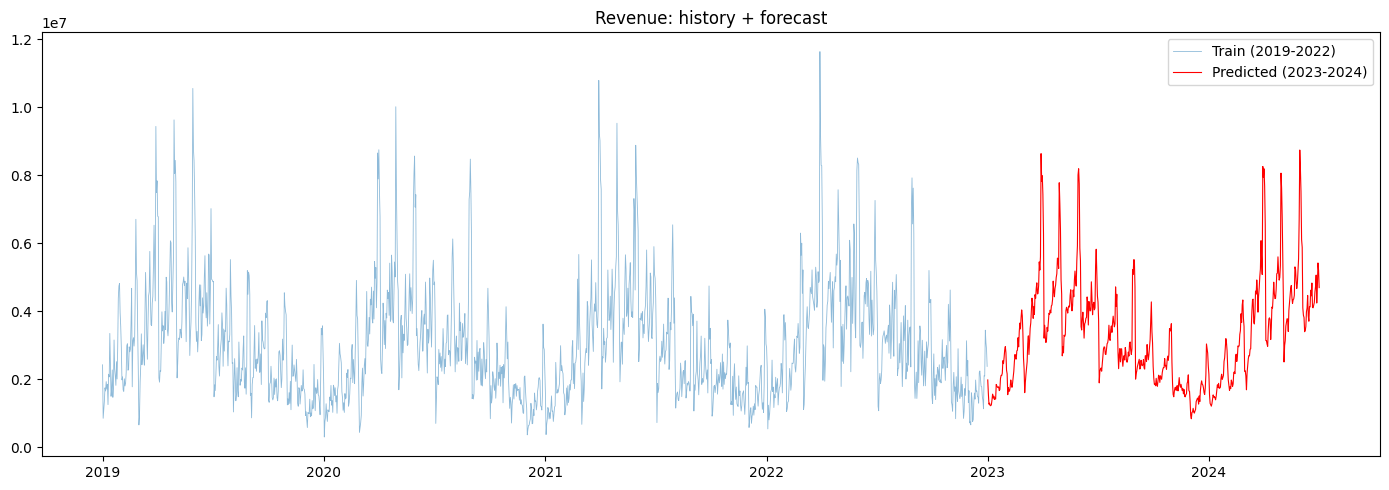

In [28]:
# ===== Sanity-check thị giác: forecast có "match" history? =====
# Nhìn xem amplitude + seasonality của 2023-2024 có giống 2019-2022 không

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.Date,     recent.Revenue,      lw=0.6, alpha=0.5, label='Train (2019-2022)')
ax.plot(submission.Date, submission.Revenue,  lw=0.8, color='red', label='Predicted (2023-2024)')
ax.set_title('Revenue: history + forecast'); ax.legend()
plt.tight_layout(); plt.show()

## 5 — Save submission.csv

In [29]:
# ===== Lưu submission.csv (Kaggle format) =====
out = submission.copy()
out['Date'] = out['Date'].dt.strftime('%Y-%m-%d')                # Timestamp → string YYYY-MM-DD

# Kaggle yêu cầu thứ tự dòng KHỚP CHÍNH XÁC sample_submission.csv
# → assert ngay để fail-fast nếu lệch (vd ai sort nhầm trước đó)
assert (out['Date'].values == sample_sub['Date'].dt.strftime('%Y-%m-%d').values).all(), 'Row order mismatch!'

out.to_csv('submission.csv', index=False)                        # index=False → không ghi cột index pandas
print(f'Saved submission.csv with {len(out)} rows')
out.head()

Saved submission.csv with 548 rows


,Date,Revenue,COGS
0,2023-01-01,1984905.55,1964403.49
1,2023-01-02,1583093.12,1331162.23
2,2023-01-03,1270976.94,956651.34
3,2023-01-04,1302733.28,977423.86
4,2023-01-05,1231304.41,962100.02


**Tại sao cần assert trước khi lưu?**

Kaggle chấm theo thứ tự dòng — nếu dòng 1 trong submission là ngày 2023-02-01 nhưng dòng 1 trong answer key là 2023-01-01 → toàn bộ submission bị lệch, score rất thấp dù model tốt. Assert này bắt lỗi đó ngay trước khi upload thay vì phát hiện sau khi thấy score 0.

## 6 — SHAP Explainability
Yêu cầu của đề: giải thích các yếu tố dẫn động doanh thu chính.

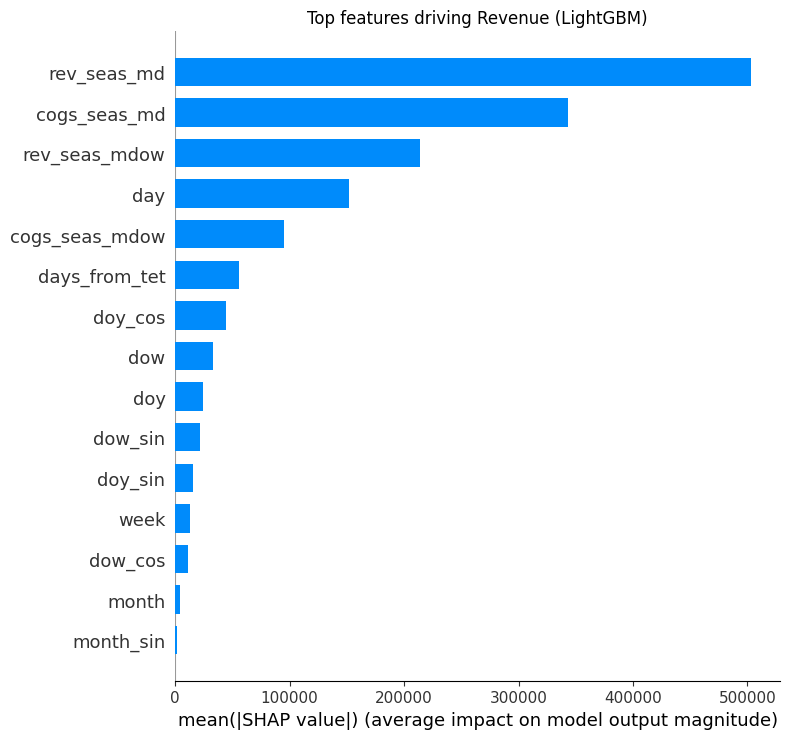

In [30]:
# ===== SHAP — bar plot ranking importance =====
# SHAP (SHapley Additive exPlanations): đo đóng góp mỗi feature vào prediction theo lý thuyết game.
# TreeExplainer = thuật toán SHAP tối ưu riêng cho tree model (LightGBM/XGBoost), nhanh hơn KernelExplainer.

explainer = shap.TreeExplainer(model_rev)                        # tạo explainer từ LGB model đã fit
sv        = explainer.shap_values(X_train_full)                  # ma trận SHAP (n_samples × n_features)

# Bar plot: |SHAP value| trung bình mỗi feature → ranking quan trọng
shap.summary_plot(sv, X_train_full, plot_type='bar', max_display=15, show=False)
plt.title('Top features driving Revenue (LightGBM)'); plt.tight_layout(); plt.show()

**SHAP không chỉ để giải thích — còn để debug model**

SHAP value của feature X cho prediction i = "feature X đóng góp bao nhiêu VND vào prediction ngày i so với baseline".

Ví dụ ngày 11/11: `base=3.5M + rev_seas_md(+1.2M) + is_1111(+2.8M) + dow(-0.1M) = 7.4M`

**Dùng SHAP để phát hiện vấn đề:**
- Feature `year` xuất hiện top SHAP → có leakage hoặc extrapolation
- `is_1111` SHAP gần 0 → feature không được học (có thể bug trong code tạo feature)
- `rev_seas_md` SHAP âm → seasonal profile bị tính ngược (impute sai)

**Tại sao `TreeExplainer` chứ không phải `KernelExplainer`?** TreeExplainer dùng thuật toán riêng cho tree-based model, chạy nhanh hơn KernelExplainer ~100× bằng cách đi theo cấu trúc cây trực tiếp thay vì sampling ngẫu nhiên.

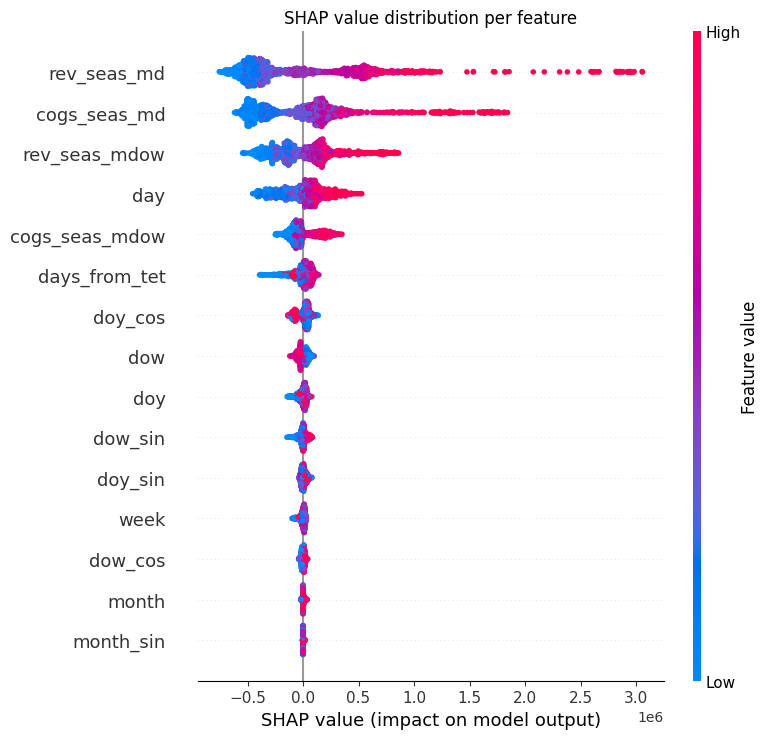

In [31]:
# ===== SHAP — beeswarm plot (chi tiết hơn bar) =====
# Mỗi điểm = 1 sample; trục x = SHAP value; màu = giá trị feature (đỏ=cao, xanh=thấp)
# → KHÔNG CHỈ thấy feature nào quan trọng mà còn HƯỚNG ảnh hưởng (high feature → tăng/giảm prediction)

shap.summary_plot(sv, X_train_full, max_display=15, show=False)
plt.title('SHAP value distribution per feature'); plt.tight_layout(); plt.show()

**Đọc beeswarm plot như thế nào?**

Mỗi **điểm** = 1 ngày trong train. **Trục x** = SHAP value (âm = kéo prediction xuống, dương = đẩy lên). **Màu** = giá trị feature (đỏ = cao, xanh = thấp).

Ví dụ đọc: nếu `rev_seas_md` có nhiều điểm đỏ bên phải → ngày có seasonal profile cao (đỏ) thì SHAP dương (đẩy prediction lên) → **hợp lý**. Nếu ngược lại (đỏ bên trái) → model học sai hướng → cần điều tra.

Beeswarm tốt hơn bar chart vì bar chỉ cho trung bình, beeswarm cho thấy **phân phối** — feature có thể vừa đẩy lên vừa kéo xuống tùy ngày (heterogeneous effect).

In [32]:
# ===== Feature importance bảng — so sánh side-by-side Revenue vs COGS =====
# .feature_importances_ của LightGBM mặc định = số lần feature được dùng để split
# (khác SHAP — đếm tần suất, không đo đóng góp); nhanh hơn nhưng kém tin cậy hơn SHAP

imp = pd.DataFrame({
    'feature':            X_train_full.columns,
    'importance_revenue': model_rev.feature_importances_,
    'importance_cogs':    model_cogs.feature_importances_,
}).sort_values('importance_revenue', ascending=False)

print('Top 15 features:')
print(imp.head(15).to_string(index=False))                       # to_string: tránh pandas truncate cột

Top 15 features:
       feature  importance_revenue  importance_cogs
   rev_seas_md                 529              465
  cogs_seas_md                 449              489
 days_from_tet                 423              349
           day                 389              459
 rev_seas_mdow                 245              193
       doy_cos                 189              228
           doy                 170              148
cogs_seas_mdow                 157              197
       doy_sin                 153              181
           dow                  86               72
       dow_cos                  62               54
       dow_sin                  53               59
          week                  53               49
         month                  11               19
     is_payday                   7                4


**`feature_importances_` vs SHAP — dùng cái nào?**

`feature_importances_` = số lần feature được dùng để **split** trong toàn bộ 2000 cây. Một feature split nhiều nhưng mỗi lần chỉ cải thiện 0.001% → không thực sự quan trọng nhưng vẫn có `importance` cao.

SHAP = đo **đóng góp thực sự** vào từng prediction → đáng tin hơn cho báo cáo và debug.

Bảng này dùng `feature_importances_` để so sánh **Revenue vs COGS** nhanh — xem 2 model có học feature giống nhau không. Nếu Revenue xếp `rev_seas_md` số 1 nhưng COGS xếp nó thấp → COGS có pattern khác, cần feature engineering riêng.

## 7 — Diễn giải kinh doanh (cho báo cáo)

Top features model học được, dịch sang ngôn ngữ kinh doanh:

1. **`rev_seas_md`** (avg revenue theo month-day): doanh thu có **tính mùa vụ rất rõ** — cùng ngày các năm trước là chỉ báo tốt nhất. → Nên duy trì lịch khuyến mãi/inventory theo chu kỳ năm.

2. **`doy_sin/cos`** (chu kỳ năm mượt): xếp cao → tồn tại pattern mùa lễ hội cuối năm + đầu năm.

3. **Tết features** (`days_from_tet`, `is_pre_tet`, `is_post_tet`): peak revenue tập trung **late Feb** (post-Tết) — khách quay lại mua sắm sau kỳ nghỉ. → Đề xuất: tăng inventory cho late Feb, lên campaign "sau Tết".

4. **Sale events** (`is_1111`, `is_blackfriday`, `is_1212`, `is_xmas`): contribution rõ → sale day-driven, cần tham gia tích cực.

5. **`dow` + `is_weekend`**: ảnh hưởng **modest** → khách mua đều trong tuần (trái với giả thuyết weekend cao hơn). Wed/Thu nhỉnh hơn Sat/Sun nhẹ.

6. **Bỏ `days_since_start`** chứng tỏ doanh nghiệp **không còn ở pha tăng trưởng tuyến tính** từ 2019. → Forecast nên dựa pattern lặp lại, không kỳ vọng tăng trưởng vô hạn.